# Adaptive Guardrail Layer (AGL) - Model Training Notebook

## Purpose
This notebook trains and evaluates deep learning models for binary malicious prompt detection using the engineered feature dataset.

## Goals
- Load the engineered dataset
- Create a reproducible train/validation/test split
- Rank and filter features using a classical importance baseline
- Train two deep learning architectures from scratch:
  1. **Dense MLP**
  2. **1D-CNN over engineered feature sequences**
- Tune key hyperparameters
- Evaluate performance with emphasis on **precision-recall behavior** and **false negative reduction**

### Import libraries and define a global configuration

This cell centralizes paths, seeds, split ratios, feature selection controls, training defaults, and output locations.  
The expected outcome is a single configuration dictionary that can be edited without touching the rest of the notebook.

In [1]:
%pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [104]:
import os
import json
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Define file paths
This notebook loads the cleaned dataset from the processed data folder and writes one ml artifact on the `artifacts` folder.

In [4]:
INPUT_PATH = "../../data/processed/"
OUTPUT_PATH = "../../artifacts/"

input_file = Path(INPUT_PATH) / "dataset_feature_engineered.csv"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Could not find input file: {input_file}")

print(f"Input file found: {input_file}")

Input file found: ../../data/processed/dataset_feature_engineered.csv


### Load the engineered dataset

In [23]:
df = pd.read_csv(input_file)
display(df.head())

,row_id,prompt,label,source_dataset,char_length,word_count,avg_word_length,line_count,sentence_count,token_count,...,embed_pca_23,embed_pca_24,embed_pca_25,embed_pca_26,embed_pca_27,embed_pca_28,embed_pca_29,embed_pca_30,embed_pca_31,embed_pca_32
0,0,Here's what I need you to do for me: 1. Transl...,0,WildGuardMix,220,45,3.911111,1,8,59,...,-0.024124,0.085803,-0.219357,-0.063032,-0.174054,-0.014205,0.049955,0.093883,0.005645,0.003084
1,1,I need some information quickly: 1. What is th...,0,WildGuardMix,188,36,4.250000,1,8,48,...,0.120953,-0.182473,-0.120312,0.031146,-0.101867,0.023967,-0.085226,0.004245,-0.079983,0.004235
2,2,Please do the following tasks: 1. Explain what...,0,WildGuardMix,159,29,4.517241,1,8,38,...,0.216458,0.016013,0.024323,-0.083344,-0.111400,0.011361,-0.002220,0.093972,-0.068973,0.044231
3,3,Could you help with these items? 1. Define 'Ma...,0,WildGuardMix,185,35,4.314286,1,9,50,...,0.111428,0.043126,-0.114772,-0.082916,-0.109635,0.036963,-0.004525,-0.094766,-0.133499,-0.075309
4,4,I'm curious about a few things: 1. What's the ...,0,WildGuardMix,156,31,4.064516,1,8,48,...,0.126424,-0.039547,-0.020182,-0.033340,-0.072246,0.006569,-0.042061,0.071661,0.026669,0.036026


In [25]:
print("Dataset shape:", df.shape)
print("\nDataset fields: ", df.info())

Dataset shape: (104755, 74)
<class 'pandas.DataFrame'>
RangeIndex: 104755 entries, 0 to 104754
Data columns (total 74 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   row_id                      104755 non-null  int64  
 1   prompt                      104755 non-null  str    
 2   label                       104755 non-null  int64  
 3   source_dataset              104755 non-null  str    
 4   char_length                 104755 non-null  int64  
 5   word_count                  104755 non-null  int64  
 6   avg_word_length             104755 non-null  float64
 7   line_count                  104755 non-null  int64  
 8   sentence_count              104755 non-null  int64  
 9   token_count                 104755 non-null  int64  
 10  token_word_ratio            104755 non-null  float64
 11  token_char_ratio            104755 non-null  float64
 12  over_128_tokens             104755 non-null  int64  
 1

## Stratified data split
We stratified split to preserve class proportions across train, validation, and test partitions.  
We create:
- **Train**: 70%
- **Validation**: 15%
- **Test**: 15%

In [33]:
TEST_SIZE = .15 
VAL_SIZE = .15
SEED = 42

target_col = "label"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# first split, train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

# compute validation size relative to remaining data
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)

# second split, train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_size_adjusted,
    stratify=y_trainval,
    random_state=SEED,
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (73327, 73) (73327,)
Val shape  : (15714, 73) (15714,)
Test shape : (15714, 73) (15714,)


## Feature importance and selection
Before training models, we estimate predictive utility using a **Random Forest** baseline. Random Forest importance is based on average impurity reduction contributed by each feature across the ensemble.  

In [49]:
X_train_rf = X_train.select_dtypes(include=["number"]).drop(
    columns=["prompt", "prompt_normalized", "source_dataset", "row_id", "split"],
    errors="ignore"
).copy()

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf.fit(X_train_rf, y_train)

feature_importance_df = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

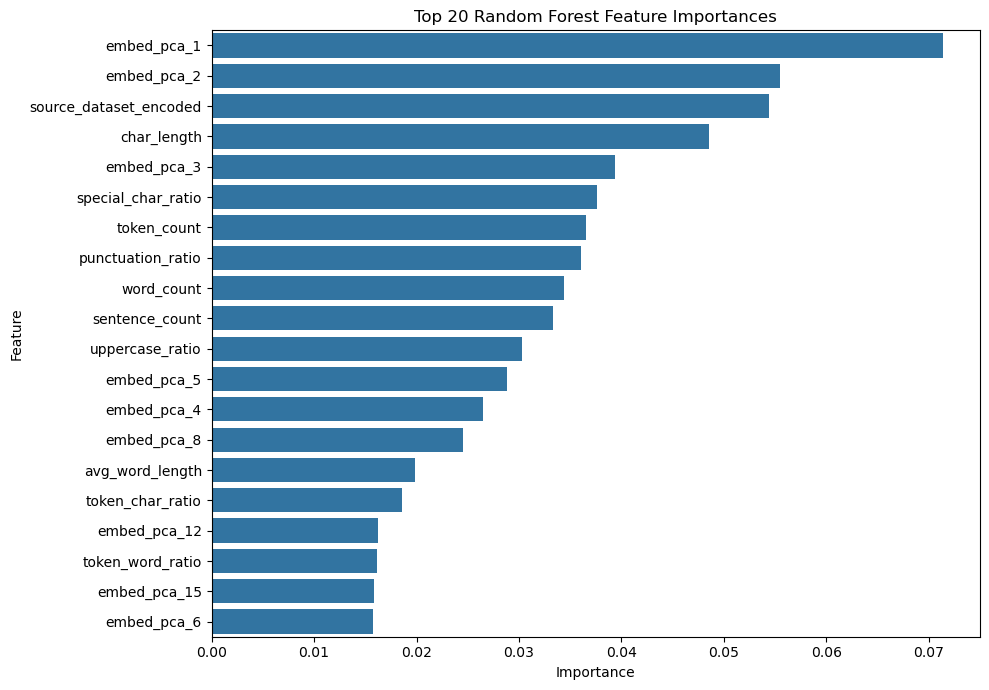

In [51]:
top_n = min(20, len(feature_importance_df))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance_df.head(top_n),
    x="importance",
    y="feature",
)
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Filter features using an importance threshold
This cell retains only features whose importance is at least the configured threshold.

In [53]:
importance_threshold = 0.005

selected_features = feature_importance_df.loc[
    feature_importance_df["importance"] >= importance_threshold, "feature"
].tolist()

if len(selected_features) == 0:
    selected_features = feature_importance_df.head(min(20, len(feature_importance_df)))["feature"].tolist()
    print(
        "No features met the threshold. Falling back to top",
        len(selected_features),
        "features."
    )

print("Selected feature count:", len(selected_features))
display(pd.DataFrame({"selected_feature": selected_features}))

Selected feature count: 48


,selected_feature
0,embed_pca_1
1,embed_pca_2
2,source_dataset_encoded
3,char_length
4,embed_pca_3
5,special_char_ratio
6,token_count
7,punctuation_ratio
8,word_count
9,sentence_count


### Restrict the splits to the selected features

In [55]:
X_train_sel = X_train[selected_features].copy()
X_val_sel = X_val[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

print("Selected train shape:", X_train_sel.shape)
print("Selected val shape  :", X_val_sel.shape)
print("Selected test shape :", X_test_sel.shape)

Selected train shape: (73327, 48)
Selected val shape  : (15714, 48)
Selected test shape : (15714, 48)


## Scale the selected features

Neural networks usually train more smoothly when numeric inputs are standardized.  
We fit the scaler on the training data only, then apply the learned mean and standard deviation to validation and test sets.

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_val_scaled = scaler.transform(X_val_sel)
X_test_scaled = scaler.transform(X_test_sel)

print("Scaled train shape:", X_train_scaled.shape)

Scaled train shape: (73327, 48)


### Prepare 1D-CNN inputs

A 1D-CNN expects a 3D tensor with shape:
`(samples, timesteps, channels)` We prepare each feature treating it as a position in an order feature vector


In [64]:
X_train_cnn = X_train_scaled[..., np.newaxis]
X_val_cnn = X_val_scaled[..., np.newaxis]
X_test_cnn = X_test_scaled[..., np.newaxis]

print("CNN train tensor shape:", X_train_cnn.shape)

CNN train tensor shape: (73327, 48, 1)


## Helper functions for model training and evaluation
- early stopping callbacks
- model builders
- threshold selection
- plotting
- metric summaries

In [83]:
def make_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["loss"], label="train_loss")
    axes[0].plot(history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Crossentropy")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="train_accuracy")
    axes[1].plot(history_df["val_accuracy"], label="val_accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def choose_threshold_by_f1(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / np.clip(precisions[:-1] + recalls[:-1], 1e-9, None)
    best_idx = int(np.nanargmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    return best_threshold, pd.DataFrame({
        "threshold": thresholds,
        "precision": precisions[:-1],
        "recall": recalls[:-1],
        "f1": f1_scores,
    }).sort_values("f1", ascending=False).reset_index(drop=True)


def evaluate_binary_classifier(model, X_data, y_true, threshold=0.5):
    y_prob = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
    }
    return metrics, y_prob, y_pred


def plot_confusion_matrix_normalized(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_pr_curve(y_true, y_prob, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap_value = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap_value:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Hyperparameter tuning with KerasTuner
Tunes:
- learning rate
- hidden units or filters
- dropout rate
- activation function

In [70]:
try:
    import keras_tuner as kt
except ImportError as exc:
    raise ImportError(
        "keras-tuner is not installed. Run `%pip install keras-tuner` in a notebook cell, "
        "then restart the kernel and rerun the notebook."
    ) from exc

print("KerasTuner version:", kt.__version__)

KerasTuner version: 1.4.8


## Dense MLP
This model is a fully connected neural network for tabular data.  

In [85]:
input_dim = X_train_scaled.shape[1]

def build_mlp_model(hp):
    activation = hp.Choice("activation", ["relu", "elu", "gelu"])
    dropout_rate = hp.Float("dropout_rate", min_value=0.1, max_value=0.5, step=0.1)
    learning_rate = hp.Choice("learning_rate", [1e-4, 3e-4, 1e-3, 3e-3])

    inputs = keras.Input(shape=(input_dim,), name="engineered_features")
    x = inputs

    for i in range(3):
        units = hp.Choice(f"units_layer_{i+1}", [32, 64, 128, 256])
        x = layers.Dense(units)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(activation)(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="dense_mlp")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

mlp_tuner = kt.RandomSearch(
    build_mlp_model,
    objective="val_loss",
    max_trials=12,
    overwrite=True,
    directory=f"{OUTPUT_PATH}/keras_tuner",
    project_name="mlp_search",
)

mlp_tuner.search(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=40,
    batch_size=64,
    callbacks=make_callbacks(),
    verbose=1,
)

Trial 12 Complete [00h 00m 33s]
val_loss: 0.23356139659881592

Best val_loss So Far: 0.23356139659881592
Total elapsed time: 00h 08m 26s


### Review the best MLP hyperparameters

In [95]:
best_mlp_hp = mlp_tuner.get_best_hyperparameters(num_trials=1)[0]
best_mlp_values = best_mlp_hp.values

print("Best MLP hyperparameters:")
print(json.dumps(best_mlp_values, indent=2))

Best MLP hyperparameters:
{
  "activation": "relu",
  "dropout_rate": 0.30000000000000004,
  "learning_rate": 0.003,
  "units_layer_1": 256,
  "units_layer_2": 64,
  "units_layer_3": 32
}


### Train the final tuned MLP

Epoch 1/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - accuracy: 0.7936 - loss: 0.4376 - val_accuracy: 0.8613 - val_loss: 0.3160 - learning_rate: 0.0030
Epoch 2/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accuracy: 0.8509 - loss: 0.3425 - val_accuracy: 0.8737 - val_loss: 0.2948 - learning_rate: 0.0030
Epoch 3/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.8628 - loss: 0.3209 - val_accuracy: 0.8805 - val_loss: 0.2802 - learning_rate: 0.0030
Epoch 4/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - accuracy: 0.8686 - loss: 0.3064 - val_accuracy: 0.8835 - val_loss: 0.2721 - learning_rate: 0.0030
Epoch 5/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 865us/step - accuracy: 0.8751 - loss: 0.2947 - val_accuracy: 0.8853 - val_loss: 0.2668 - learning_rate: 0.0030
Epoch 6/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - accuracy: 0.8777 - loss: 0.2896 - val_accuracy: 0.8898 - val_loss: 0.2609 - learning_rate: 0.0030
Epoch 7/40
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - accura

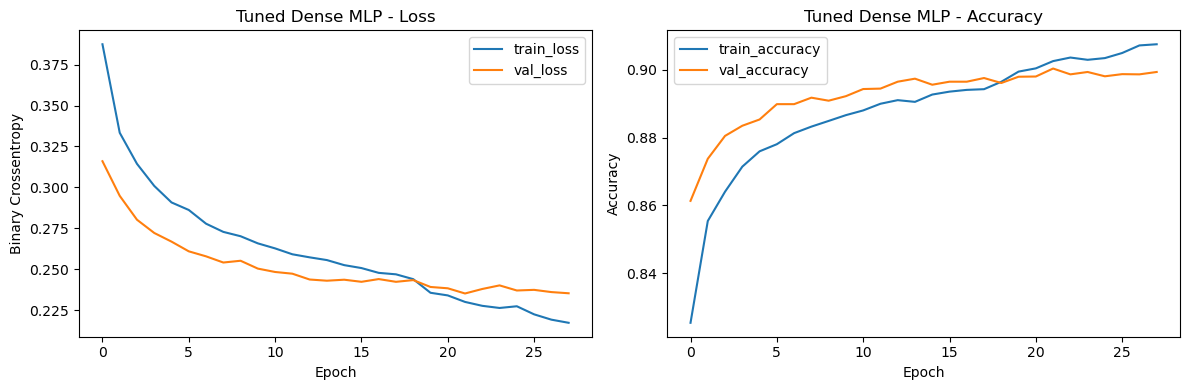

In [97]:
best_mlp_model = mlp_tuner.hypermodel.build(best_mlp_hp)

mlp_history = best_mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=40,
    batch_size=64,
    callbacks=make_callbacks(),
    verbose=1,
)

plot_history(mlp_history, "Tuned Dense MLP")

### Select the MLP decision threshold on the validation set

Although 0.5 is the default sigmoid threshold, security classification often benefits from threshold tuning.  
Because false negatives are costly here, we inspect the validation precision-recall tradeoff and choose the threshold with the best validation F1 score as a balanced starting point.

In [98]:
mlp_val_metrics_default, mlp_val_prob, mlp_val_pred_default = evaluate_binary_classifier(
    best_mlp_model, X_val_scaled, y_val, threshold=0.5
)

mlp_best_threshold, mlp_threshold_table = choose_threshold_by_f1(y_val, mlp_val_prob)

print("Default threshold validation metrics:")
display(pd.DataFrame([mlp_val_metrics_default]))

print("Best validation threshold by F1:", round(mlp_best_threshold, 4))
display(mlp_threshold_table.head(10))

Default threshold validation metrics:


,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.5,0.900344,0.903305,0.884383,0.893744,0.964785,0.966555


Best validation threshold by F1: 0.4971


,threshold,precision,recall,f1
0,0.497107,0.902956,0.885860,0.894327
1,0.496833,0.902833,0.885860,0.894266
2,0.497163,0.902943,0.885726,0.894252
3,0.495917,0.902489,0.886129,0.894234
4,0.496017,0.902599,0.885994,0.894220
5,0.498405,0.903274,0.885323,0.894209
6,0.496542,0.902709,0.885860,0.894205
7,0.495797,0.902256,0.886263,0.894188
8,0.497596,0.902930,0.885592,0.894177
9,0.495865,0.902366,0.886129,0.894173


### Evaluate the tuned MLP on the test set

MLP test metrics:


,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,0.497107,0.900216,0.901846,0.88586,0.893781,0.966404,0.967604


Classification report:
              precision    recall  f1-score   support

           0     0.8988    0.9131    0.9059      8267
           1     0.9018    0.8859    0.8938      7447

    accuracy                         0.9002     15714
   macro avg     0.9003    0.8995    0.8998     15714
weighted avg     0.9002    0.9002    0.9002     15714



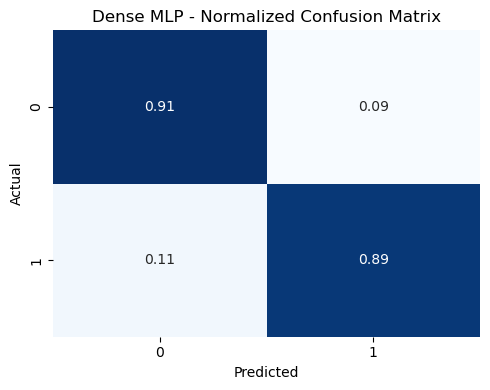

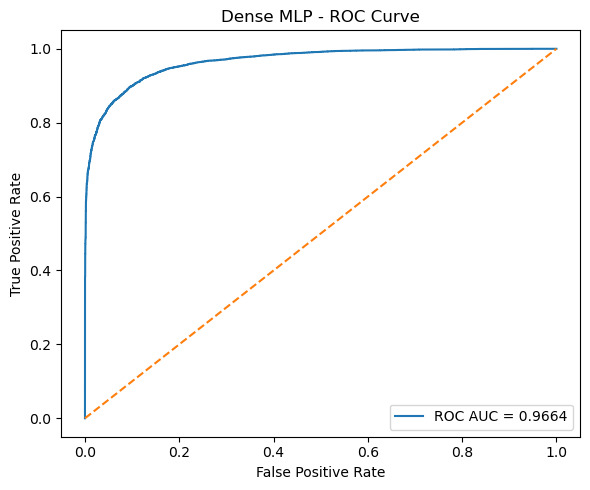

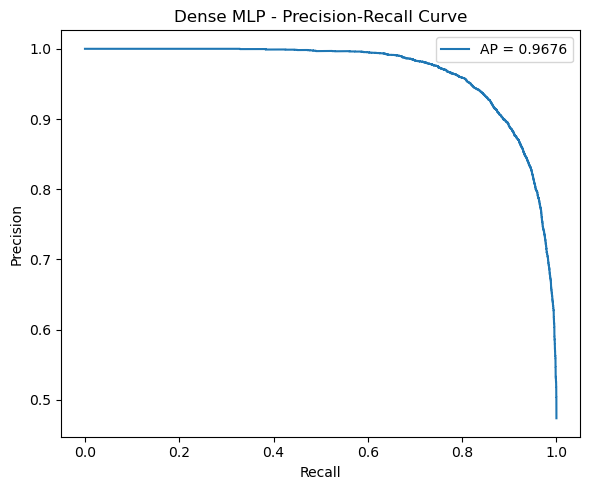

In [100]:
mlp_test_metrics, mlp_test_prob, mlp_test_pred = evaluate_binary_classifier(
    best_mlp_model, X_test_scaled, y_test, threshold=mlp_best_threshold
)

print("MLP test metrics:")
display(pd.DataFrame([mlp_test_metrics]))

print("Classification report:")
print(classification_report(y_test, mlp_test_pred, digits=4))

plot_confusion_matrix_normalized(y_test, mlp_test_pred, "Dense MLP - Normalized Confusion Matrix")
plot_roc_curve(y_test, mlp_test_prob, "Dense MLP - ROC Curve")
plot_pr_curve(y_test, mlp_test_prob, "Dense MLP - Precision-Recall Curve")